# 02 — Unsupervised Learning
This notebook performs unsupervised exploration of the four scRNA-seq datasets:

| Technology | Cell line | Train cells | Genes |
|------------|-----------|-------------|-------|
| SmartSeq   | MCF7      | 250         | 3 000 |
| SmartSeq   | HCC1806   | 182         | 3 000 |
| DropSeq    | MCF7      | 21 626      | 3 000 |
| DropSeq    | HCC1806   | 14 682      | 3 000 |

**Goals:**
1. Cell–cell correlation heatmaps + outlier flagging
2. PCA on all datasets — scree plots, variance explained, PC1 vs PC2 coloured by label
3. K-means + hierarchical clustering with silhouette scores
4. Cross-dataset comparison: MCF7 vs HCC1806 · SmartSeq vs DropSeq

---
**Key preprocessing note (from preprocessing):**
- **Both SmartSeq and DropSeq** curator files contain integer counts → we apply `log2(x + 1)` here before PCA/clustering
- Both datasets are then **z-scored per gene** (mean=0, std=1) so PCA treats all genes equally regardless of absolute expression level

## 0. Setup

In [2]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

#reproducability
RNG = np.random.default_rng(42)
RANDOM_STATE = 42

ROOT = Path.cwd().parent #repo root
DATA = ROOT / 'data'
SMART = DATA / 'SmartSeq'
DROP = DATA / 'DropSeq'
OUT = ROOT / 'outputs'

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(context='notebook', style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

#sanity check
for label, p in [('ROOT', ROOT), ('DATA', DATA), ('SMART', SMART), ('DROP', DROP), ('OUT', OUT)]:
    print(f'{label:<6}: exists={p.exists()}  {p}')

ROOT  : exists=True  c:\Users\carol\Desktop\AI lab\hypoxia-classifier
DATA  : exists=True  c:\Users\carol\Desktop\AI lab\hypoxia-classifier\data
SMART : exists=True  c:\Users\carol\Desktop\AI lab\hypoxia-classifier\data\SmartSeq
DROP  : exists=True  c:\Users\carol\Desktop\AI lab\hypoxia-classifier\data\DropSeq
OUT   : exists=True  c:\Users\carol\Desktop\AI lab\hypoxia-classifier\outputs


## 1. Load data

We load directly from the curator-provided files.  
We use **train splits only** for unsupervised analysis (no label leakage risk, but good practice).  

- SmartSeq filenames: `{line}_SmartS_Filtered_Normalised_3000_Data_train.txt`
- DropSeq filenames:  `{line}_Filtered_Normalised_3000_Data_train.txt`

Each matrix is **genes (rows) × cells (columns)**.

In [4]:
def load_matrix(path: Path) -> pd.DataFrame:
    """Load a gene × cell expression matrix (whitespace-separated, gene-symbol row index)."""
    return pd.read_csv(path, sep=r'\s+', engine='python', index_col=0)

COND_RE = re.compile(r'(Hypoxia|Normoxia|Hypo|Norm)', re.IGNORECASE)
_COND_MAP = {'Hypo': 'Hypoxia', 'Hypoxia': 'Hypoxia', 'Norm': 'Normoxia', 'Normoxia': 'Normoxia'}

def parse_condition(col: str) -> str:
    m = COND_RE.search(col)
    return _COND_MAP.get(m.group(1), 'Unknown') if m else 'Unknown'

def condition_series(df: pd.DataFrame) -> pd.Series:
    return pd.Series([parse_condition(c) for c in df.columns], index=df.columns, name='condition')

#load matrices
datasets = {
    ('SmartSeq', 'MCF7'): load_matrix(SMART/'MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt'),
    ('SmartSeq', 'HCC1806'): load_matrix(SMART/'HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt'),
    ('DropSeq', 'MCF7'): load_matrix(DROP/'MCF7_Filtered_Normalised_3000_Data_train.txt'),
    ('DropSeq', 'HCC1806'): load_matrix(DROP/'HCC1806_Filtered_Normalised_3000_Data_train.txt'),
}

print(f"{'Technology':<12} {'Cell line':<10} {'Genes':>7} {'Cells':>8}  dtype")
print('─' * 55)
for (tech, line), df in datasets.items():
    print(f"{tech:<12} {line:<10} {df.shape[0]:>7,} {df.shape[1]:>8,}  {df.dtypes.iloc[0]}")

Technology   Cell line    Genes    Cells  dtype
───────────────────────────────────────────────────────
SmartSeq     MCF7         3,000      250  int64
SmartSeq     HCC1806      3,000      182  int64
DropSeq      MCF7         3,000   21,626  int64
DropSeq      HCC1806      3,000   14,682  int64


**What to check in the output above:**
- All four datasets show `int64` dtype → integer counts, all need `log2(x+1)` in Section 2

## 2. Preprocessing for unsupervised analysis

Two steps:
1. **Log transform** (both SmartSeq and DropSeq): `log2(x + 1)` compresses the dynamic range and stabilises variance, making PCA and distance metrics more meaningful (deferred from preprocessing).
2. **Z-score per gene** across all cells: brings every gene to mean=0, std=1 so that highly-expressed genes don't dominate PCA axes purely because of their scale.

In [5]:
def preprocess(df: pd.DataFrame, tech: str) -> np.ndarray:
    """
    Prepare a cells × genes matrix for PCA / clustering.
    - Both SmartSeq and DropSeq: log2(x+1) transform, then z-score each gene
    Returns: np.ndarray of shape (n_cells, n_genes)
    """
    X = df.values.T.astype(float) #transpose
    X = np.log2(X + 1)
    X_scaled = StandardScaler().fit_transform(X) #z-score per gene
    return X_scaled

X_dict = {}
cond_dict = {}

for (tech, line), df in datasets.items():
    X_dict[(tech, line)] = preprocess(df, tech)
    cond_dict[(tech, line)] = condition_series(df).values

print('Preprocessing complete.')
for key, X in X_dict.items():
    print(f"{key[0]} {key[1]}:{X.shape}(cells × genes)")

Preprocessing complete.
SmartSeq MCF7:(250, 3000)(cells × genes)
SmartSeq HCC1806:(182, 3000)(cells × genes)
DropSeq MCF7:(21626, 3000)(cells × genes)
DropSeq HCC1806:(14682, 3000)(cells × genes)


## 3. Cell–cell Pearson correlation heatmaps

Each entry (i, j) shows the Pearson correlation between cell i and cell j across all 3 000 genes.  

**What to look for:**
- A **block-diagonal** pattern after sorting by condition means Hypoxia and Normoxia cells are transcriptionally distinct → good separability for classification downstream
- Cells with **uniformly low correlation** to all others are potential outliers (empty wells, doublets, failed libraries)

> DropSeq has ~15 000–21 000 cells — plotting the full matrix is impossible. We **subsample 400 cells** (200 per condition) for visualisation only. All other analyses use the full dataset.

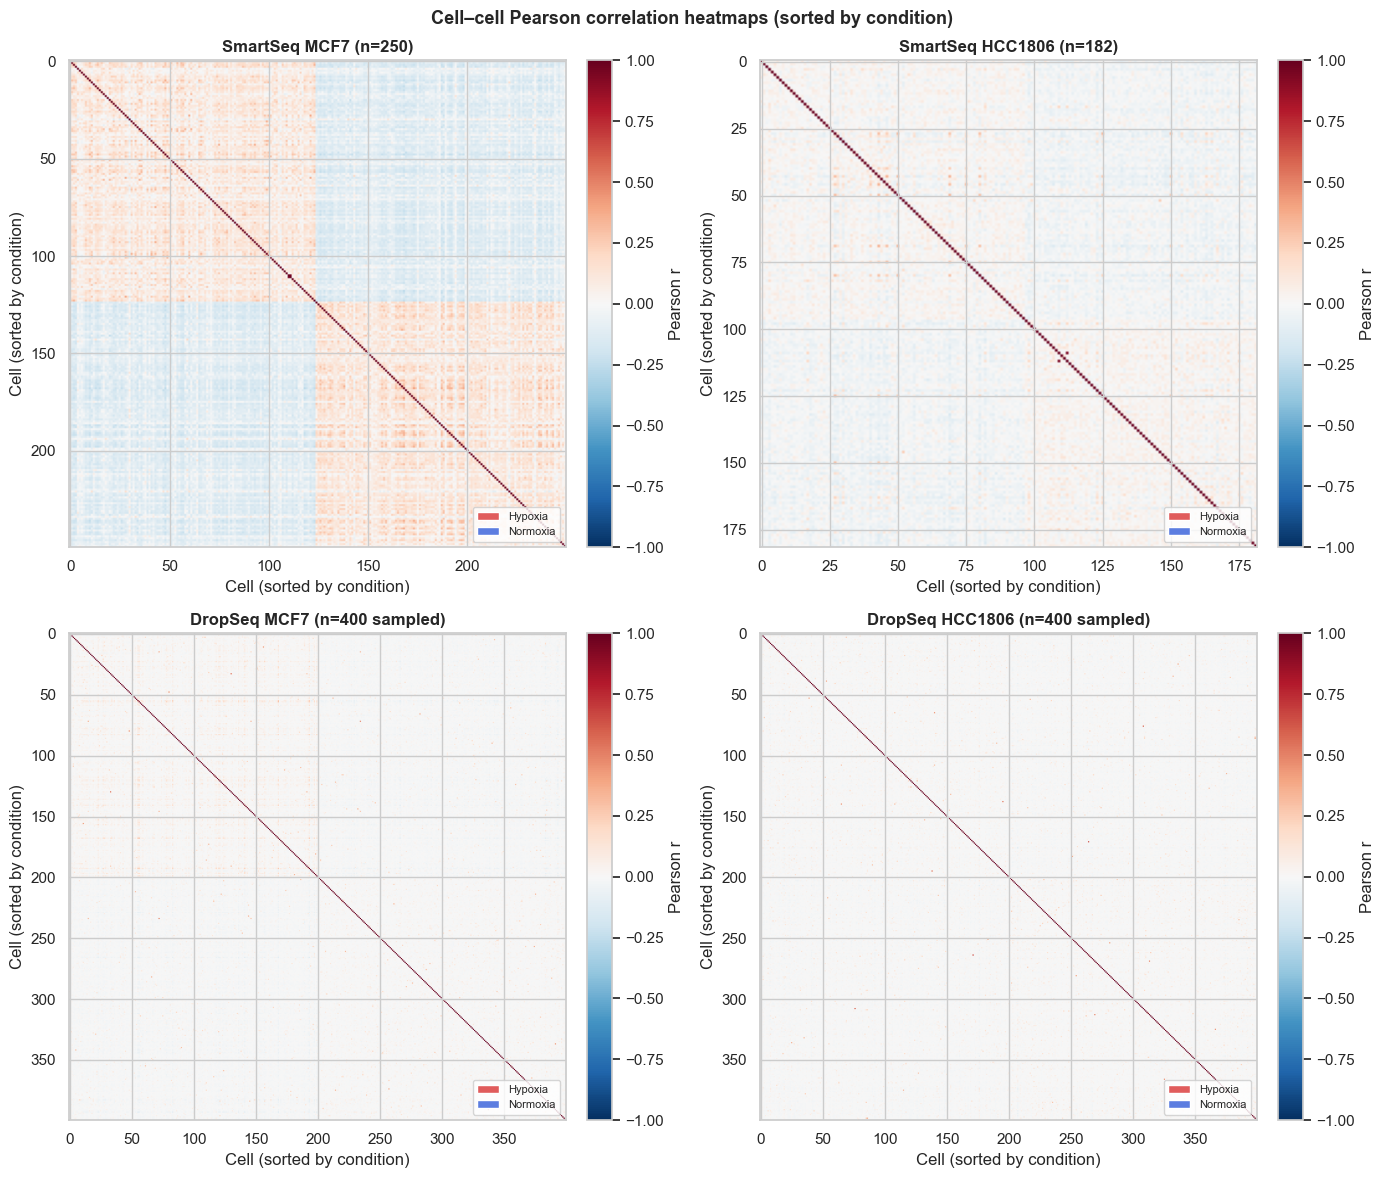

Saved: outputs/unsupervised_corr_heatmaps.png


In [21]:
MAX_HEATMAP = 400 #cells to display in heatmap

def stratified_idx(conditions: np.ndarray, n: int, rng) -> np.ndarray:
    """Return up to n indices balanced across unique condition values."""
    unique = np.unique(conditions)
    per_class = n // len(unique)
    idx_list = []
    for c in unique:
        idx_c = np.where(conditions == c)[0]
        idx_list.append(rng.choice(idx_c, size=min(per_class, len(idx_c)), replace=False))
    return np.sort(np.concatenate(idx_list))


COND_COL = {'Hypoxia': '#e05c5c', 'Normoxia': '#5c7de0'}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, ((tech, line), X) in zip(axes, X_dict.items()):
    conds = cond_dict[(tech, line)]

    if X.shape[0] > MAX_HEATMAP:
        idx = stratified_idx(conds, MAX_HEATMAP, RNG)
        X_s, c_s = X[idx], conds[idx]
        note = f'n={len(idx)} sampled'
    else:
        X_s, c_s = X, conds
        note = f'n={X.shape[0]}'

    order = np.argsort(c_s, kind='stable')
    X_s, c_s = X_s[order], c_s[order]

    corr = np.corrcoef(X_s)

    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')

    ax.set_title(f'{tech} {line} ({note})', fontweight='bold')
    ax.set_xlabel('Cell (sorted by condition)')
    ax.set_ylabel('Cell (sorted by condition)')

    legend_elems = [mpatches.Patch(facecolor=COND_COL['Hypoxia'],  label='Hypoxia'), mpatches.Patch(facecolor=COND_COL['Normoxia'], label='Normoxia')]
    ax.legend(handles=legend_elems, loc='lower right', fontsize=8)

fig.suptitle('Cell–cell Pearson correlation heatmaps (sorted by condition)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / 'unsupervised_corr_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/unsupervised_corr_heatmaps.png')

### Interpretation — Correlation Heatmaps

**What the plot shows:**
Each heatmap is a grid where colour at position (i, j) = how similar cell i is to cell j across all 3,000 genes (red = similar, blue = different, white = no relationship). Cells are sorted Hypoxia first, then Normoxia.

**Results:**
- **SmartSeq MCF7:** Clear block-diagonal. Hypoxia cells are similar to each other (warm top-left block), Normoxia cells are similar to each other (warm bottom-right block), and the two conditions are dissimilar to each other (pale off-diagonal). Strong result.
- **SmartSeq HCC1806:** Same pattern but weaker. The bright red dots around row/column 110 are the 4 outlier cells flagged in Section 3.1, highly correlated with each other, poorly with everyone else.
- **DropSeq:** Nearly no visible structure (everything pale ≈ r = 0). Not because the biology is absent, but because DropSeq cells have so many zero counts (dropout) that correlations collapse toward zero regardless of condition. The signal exists but needs PCA/clustering to surface it.

**Why it matters:**
The block structure confirms that the hypoxia response is the dominant driver of cell-to-cell expression differences.

### 3.1 Flag outlier cells

A cell is an **outlier** if its mean Pearson correlation with all other cells is more than 3 standard deviations below the dataset mean.  
These cells are **reported but not removed** — removal is Person D's decision.

In [7]:
SD_THRESHOLD = 3.0
outlier_rows = []

for (tech, line), X in X_dict.items():
    corr = np.corrcoef(X)
    np.fill_diagonal(corr, np.nan) #exclude self-correlation
    mean_corr = np.nanmean(corr, axis=1) #mean correlation of each cell vs all others

    mu, sd = np.nanmean(mean_corr), np.nanstd(mean_corr)
    threshold = mu - SD_THRESHOLD * sd
    outlier_mask = mean_corr < threshold

    col_names = datasets[(tech, line)].columns
    n_out = outlier_mask.sum()
    print(f"{tech:10s} {line:8s}: μ={mu:.3f}, σ={sd:.3f}, threshold={threshold:.3f} → {n_out} outlier(s)")

    for idx in np.where(outlier_mask)[0]:
        outlier_rows.append({'Technology': tech, 'Cell line': line,
                              'Cell': col_names[idx],
                              'Mean corr': round(float(mean_corr[idx]), 4),
                              'Threshold': round(float(threshold), 4)})

outlier_df = pd.DataFrame(outlier_rows)
print()
if outlier_df.empty:
    print('No outliers detected across all datasets.')
else:
    print(outlier_df.to_string(index=False))

SmartSeq   MCF7    : μ=-0.004, σ=0.004, threshold=-0.015 → 0 outlier(s)
SmartSeq   HCC1806 : μ=-0.005, σ=0.003, threshold=-0.014 → 4 outlier(s)
DropSeq    MCF7    : μ=0.000, σ=0.002, threshold=-0.005 → 0 outlier(s)
DropSeq    HCC1806 : μ=-0.000, σ=0.000, threshold=-0.001 → 0 outlier(s)

Technology Cell line                                                                 Cell  Mean corr  Threshold
  SmartSeq   HCC1806  "output.STAR.PCRPlate3A5_Hypoxia_S75_Aligned.sortedByCoord.out.bam"     -0.015     -0.014
  SmartSeq   HCC1806  "output.STAR.PCRPlate3B3_Hypoxia_S70_Aligned.sortedByCoord.out.bam"     -0.016     -0.014
  SmartSeq   HCC1806 "output.STAR.PCRPlate3C2_Hypoxia_S167_Aligned.sortedByCoord.out.bam"     -0.014     -0.014
  SmartSeq   HCC1806  "output.STAR.PCRPlate3G4_Hypoxia_S73_Aligned.sortedByCoord.out.bam"     -0.016     -0.014


### Interpretation — Outlier Flagging

| Dataset | Outliers found |
|---------|---------------|
| SmartSeq MCF7 | 0 |
| SmartSeq HCC1806 | **4** (all in Hypoxia) |
| DropSeq MCF7 | 0 |
| DropSeq HCC1806 | 0 |

**Interpretation:**
- Three datasets are clean. SmartSeq HCC1806 has 4 Hypoxia cells whose mean correlation to all other cells is unusually low (more than 3 SD below average); they don't look like the rest of the group.
- These could be failed cell preparations, cells that didn't respond to hypoxia as strongly, or contamination. We flag them but don't remove them, that's left to Person D.
- No outliers in DropSeq because the per-cell correlations are already near zero for everyone (due to dropout), so nothing stands out as unusually low.

## 4. PCA — Principal Component Analysis

PCA rotates the 3 000-dimensional gene-expression space to find the directions of maximum variance.  
Because we z-scored first, every gene contributes equally in terms of scale. The PCs capture pure biological signal.

For each dataset:
- **Scree plot**: bar chart of variance explained per PC + cumulative curve
- **PC1 vs PC2 scatter**: coloured by Hypoxia / Normoxia to see if PCA separates the two conditions without ever seeing the labels

In [9]:
N_COMPONENTS = 30 #compute top-30 PCs

pca_dict = {} #fitted PCA objects
scores_dict = {} #PCA-transformed coordinates(cells × PCs)

for (tech, line), X in X_dict.items():
    n_comp = min(N_COMPONENTS, X.shape[0] - 1, X.shape[1])
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    scores = pca.fit_transform(X)
    pca_dict[(tech, line)] = pca
    scores_dict[(tech, line)] = scores
    total_var = pca.explained_variance_ratio_.sum() * 100

    print(f"{tech:10s} {line:8s}: top-{n_comp} PCs explain {total_var:.1f}% of variance")

SmartSeq   MCF7    : top-30 PCs explain 37.7% of variance
SmartSeq   HCC1806 : top-30 PCs explain 35.2% of variance
DropSeq    MCF7    : top-30 PCs explain 3.1% of variance
DropSeq    HCC1806 : top-30 PCs explain 2.9% of variance


> **Note:** SmartSeq's top 30 PCs capture ~36–38% of total variance, while DropSeq's capture only ~3%.
> This gap is expected since DropSeq's high dropout spreads variance thinly across thousands of dimensions
> rather than concentrating it in a few meaningful components. All subsequent PCA and clustering results
> should be read with this in mind.

### 4.1 Scree plots

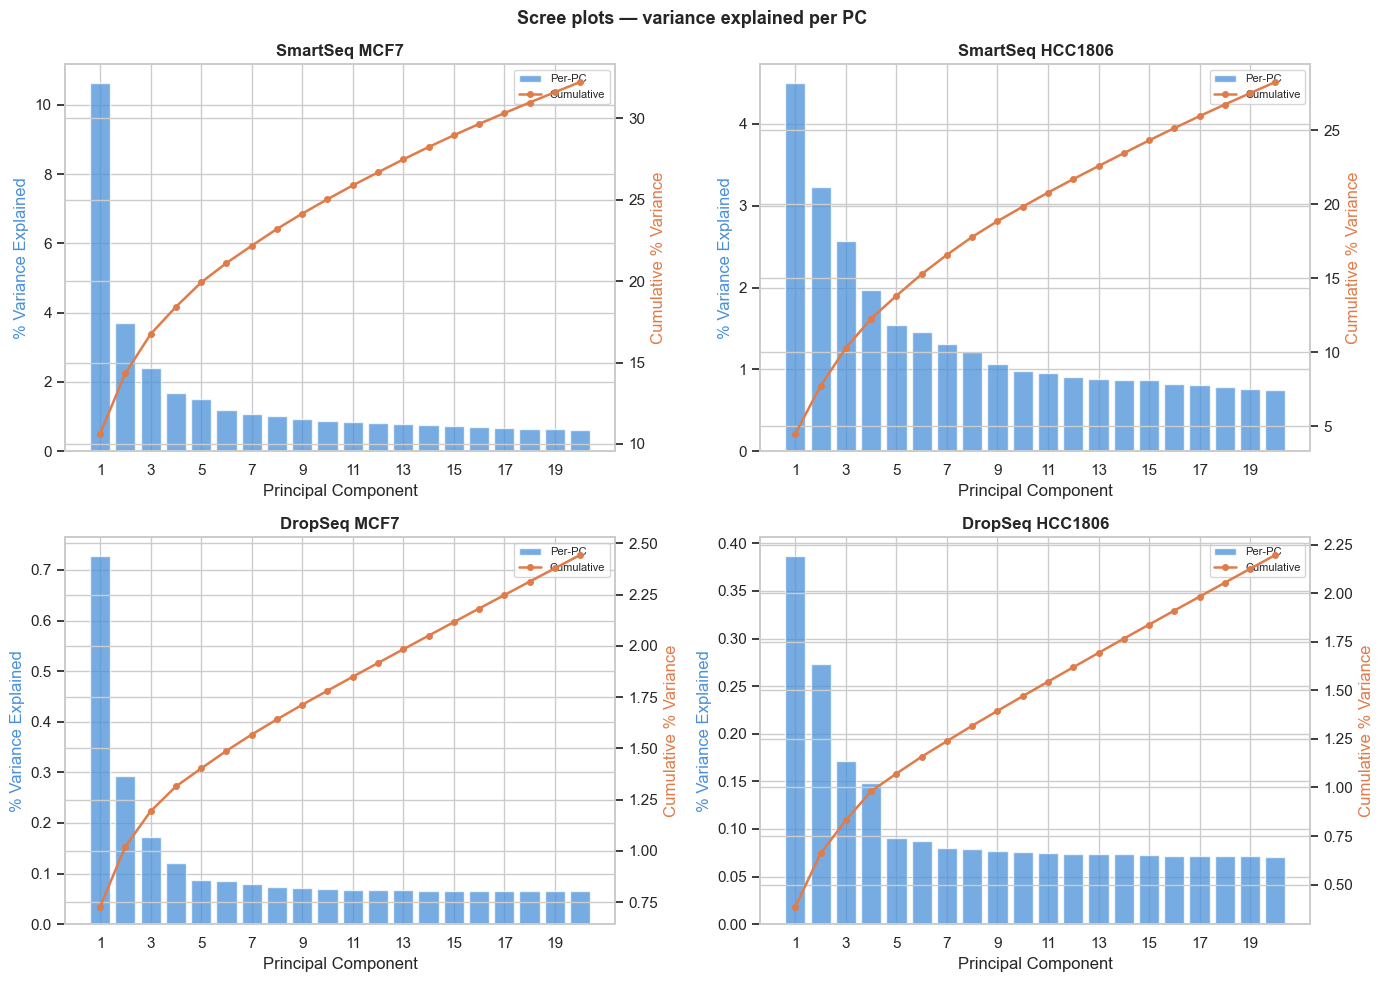

Saved: outputs/unsupervised_scree_plots.png


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, ((tech, line), pca) in zip(axes, pca_dict.items()):
    n_show = min(20, len(pca.explained_variance_ratio_))
    ev = pca.explained_variance_ratio_[:n_show] * 100
    cumev = np.cumsum(pca.explained_variance_ratio_) * 100

    ax2 = ax.twinx()
    ax.bar(range(1, n_show + 1), ev, color='#4a90d9', alpha=0.75, label='Per-PC')
    ax2.plot(range(1, n_show + 1), cumev[:n_show], color='#e07b4a', marker='o', ms=4, lw=1.8, label='Cumulative')

    ax.set_xlabel('Principal Component')
    ax.set_ylabel('% Variance Explained', color='#4a90d9')
    ax2.set_ylabel('Cumulative % Variance', color='#e07b4a')
    ax.set_title(f'{tech} {line}', fontweight='bold')
    ax.set_xticks(range(1, n_show + 1, 2))

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right')

fig.suptitle('Scree plots — variance explained per PC', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / 'unsupervised_scree_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/unsupervised_scree_plots.png')

### Interpretation — Scree Plots

**What the plot shows:**
Each bar is one PC and its height is how much of the total variance that PC captures alone. The orange line is the running cumulative total. A steep drop after the first few bars (an "elbow") means most of the biological signal is concentrated in just a few dimensions.

**Results:**
| Dataset | Variance explained by top 30 PCs |
|---------|----------------------------------|
| SmartSeq MCF7 | **37.7%** |
| SmartSeq HCC1806 | **35.2%** |
| DropSeq MCF7 | **3.1%** |
| DropSeq HCC1806 | **2.9%** |

**Interpretation:**
- **SmartSeq:** Clear elbow after PC1–PC2, with PC1 alone explaining ~10% (MCF7) and ~4.5% (HCC1806). Most biological signal is captured in the first few components, so the hypoxia response is the dominant axis of variation.
- **DropSeq:** No clear elbow, the bars are all similarly small and the cumulative line rises almost linearly. Only ~3% of variance in 30 PCs. This is the dropout effect: variance is spread thinly across thousands of dimensions rather than concentrated in a few meaningful ones. The signal exists but is diluted.
- **Why it matters:** This gap between SmartSeq and DropSeq explains why all subsequent results look cleaner for SmartSeq: better separation in PCA scatter, higher silhouette scores, clearer clustering.

### 4.2 PC1 vs PC2 — coloured by Hypoxia / Normoxia

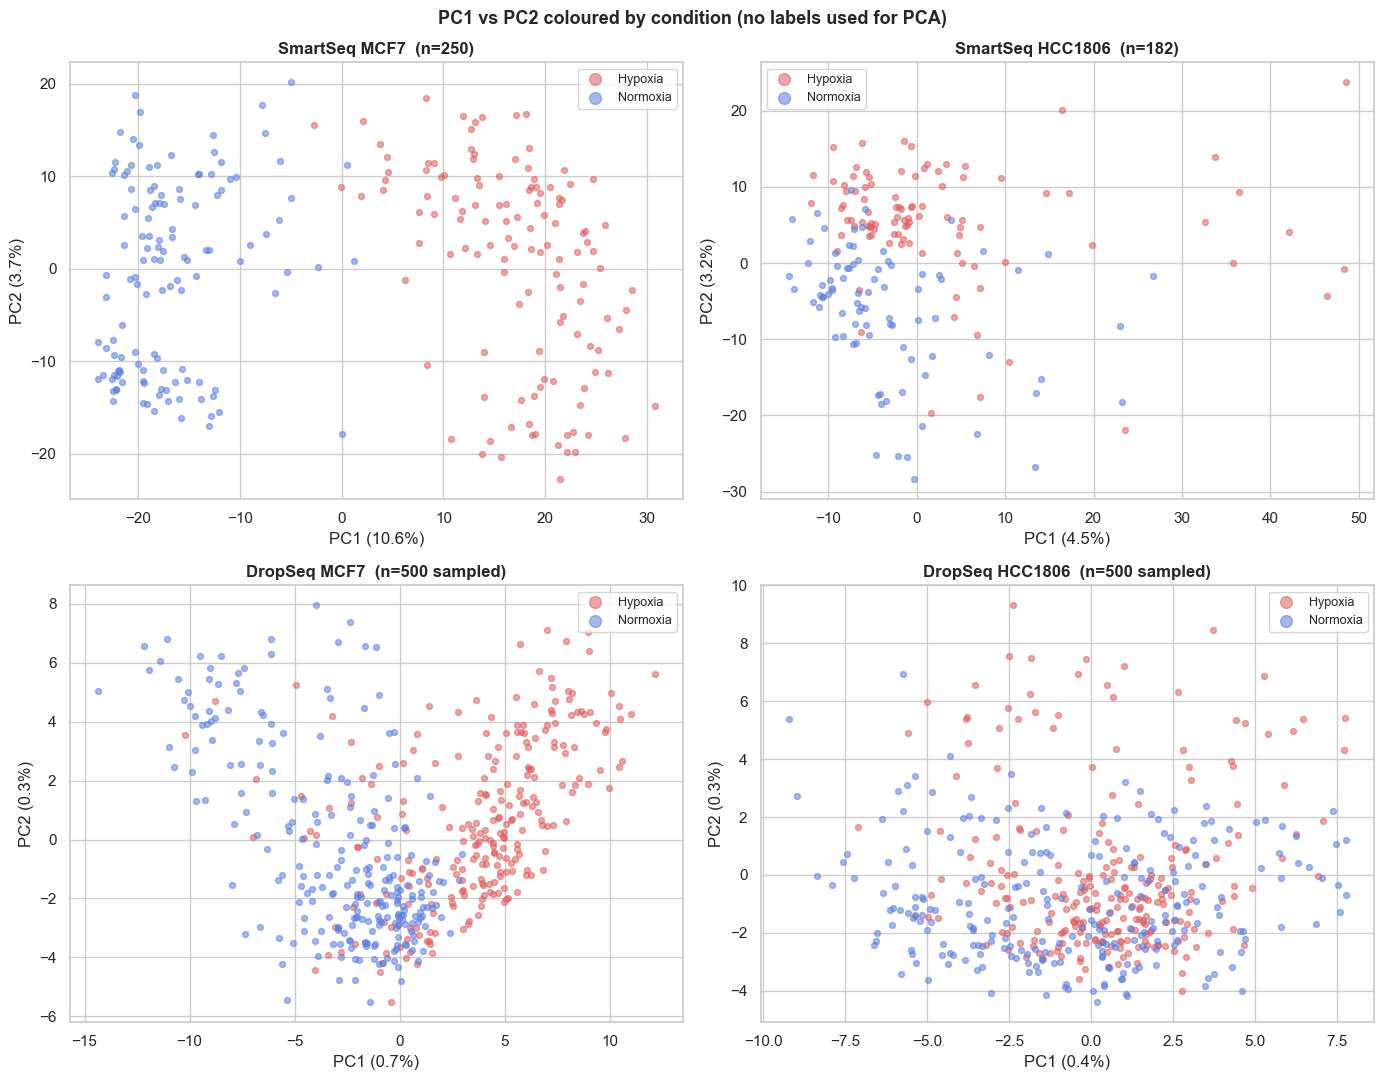

Saved: outputs/unsupervised_pca_pc1_pc2.png


In [23]:
MAX_SCATTER = 500

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, ((tech, line), scores) in zip(axes, scores_dict.items()):
    pca = pca_dict[(tech, line)]
    conds = cond_dict[(tech, line)]

    if scores.shape[0] > MAX_SCATTER:
        idx = stratified_idx(conds, MAX_SCATTER, RNG)
        s_plot = scores[idx, :2]
        c_plot = conds[idx]
        note = f'n={len(idx)} sampled'
    else:
        s_plot, c_plot = scores[:, :2], conds
        note = f'n={scores.shape[0]}'

    for cond, color in COND_COL.items():
        mask = c_plot == cond
        ax.scatter(s_plot[mask, 0], s_plot[mask, 1], color=color, alpha=0.55, s=18, label=cond, rasterized=True)

    ev1 = pca.explained_variance_ratio_[0] * 100
    ev2 = pca.explained_variance_ratio_[1] * 100
    ax.set_xlabel(f'PC1 ({ev1:.1f}%)')
    ax.set_ylabel(f'PC2 ({ev2:.1f}%)')
    ax.set_title(f'{tech} {line}  ({note})', fontweight='bold')
    ax.legend(fontsize=9, markerscale=2)

fig.suptitle('PC1 vs PC2 coloured by condition (no labels used for PCA)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / 'unsupervised_pca_pc1_pc2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/unsupervised_pca_pc1_pc2.png')

### Interpretation — PC1 vs PC2 Scatter

**What the plot shows:**
Each dot is a cell, plotted by its position on the two most important PCA axes. Colour = condition (red = Hypoxia, blue = Normoxia). PCA never sees the labels, so if the colours separate, it means the biology is doing that, not us.

**Interpretation:**
- **SmartSeq MCF7:** The clearest result, two distinct clouds separated along PC1 (10.6%). PC1 is effectively the Hypoxia/Normoxia axis. Best-case outcome.
- **SmartSeq HCC1806:** Decent separation but more overlap than MCF7. HCC1806 has a different baseline expression profile (triple-negative vs ER+), so other sources of variation compete with the hypoxia signal along PC1 (4.5%).
- **DropSeq:** Both clouds overlap heavily. Expected: dropout noise drowns out the per-cell signal, and PC1 explains less than 1%. The separation trend is still directionally there but not visually clean.
- **Key message:** Even without labels, PCA separates the two conditions, confirming that hypoxia is the dominant source of variation in these cells and giving Person D a strong signal to classify.

## 5. Clustering

We cluster in **PCA-reduced space** (top PCs explaining ≥ 80% variance, capped at 10) rather than the full 3 000-gene space. This:
- Reduces noise (later PCs are mostly noise)
- Makes DropSeq clustering computationally feasible

We apply two complementary methods:

| Method | Idea | When useful |
|--------|------|-------------|
| **K-means** | Assign cells to K clusters minimising within-cluster variance | Fast, works at DropSeq scale |
| **Hierarchical (Ward)** | Build a tree of merges using Ward linkage | Gives a dendrogram showing merge structure |

In [12]:
def n_pcs_for_variance(pca: PCA, target: float = 0.80, max_pcs: int = 10) -> int:
    """How many PCs are needed to explain at least `target` fraction of variance?"""
    cum = np.cumsum(pca.explained_variance_ratio_)
    n = int(np.searchsorted(cum, target)) + 1
    return min(n, max_pcs, len(pca.explained_variance_ratio_))


X_pca = {} #reduced spaces for clustering
for (tech, line), scores in scores_dict.items():
    pca = pca_dict[(tech, line)]
    n_pc = n_pcs_for_variance(pca)
    X_pca[(tech, line)] = scores[:, :n_pc]
    var_explained = pca.explained_variance_ratio_[:n_pc].sum() * 100
    print(f"{tech:10s} {line:8s}: using top {n_pc} PCs → {var_explained:.1f}% variance")

SmartSeq   MCF7    : using top 10 PCs → 25.0% variance
SmartSeq   HCC1806 : using top 10 PCs → 19.8% variance
DropSeq    MCF7    : using top 10 PCs → 1.8% variance
DropSeq    HCC1806 : using top 10 PCs → 1.5% variance


> **Note:** All four datasets hit the 10 PC cap before reaching 80% cumulative variance, meaning the data
> is high-dimensional and no small set of PCs dominates completely. We cap at 10 to keep clustering
> computationally feasible, accepting that we retain 25% (SmartSeq MCF7) down to 1.5% (DropSeq HCC1806)
> of total variance. This is sufficient for clustering. The top PCs still capture the strongest biological
> signal even if they don't explain the majority of variance.

### 5.1 Silhouette analysis — choosing the best K for K-means

The **silhouette score** measures how well each cell fits its own cluster vs the nearest other cluster.  
Range: −1 (wrong cluster) to +1 (perfectly assigned). We pick the K with the highest score.

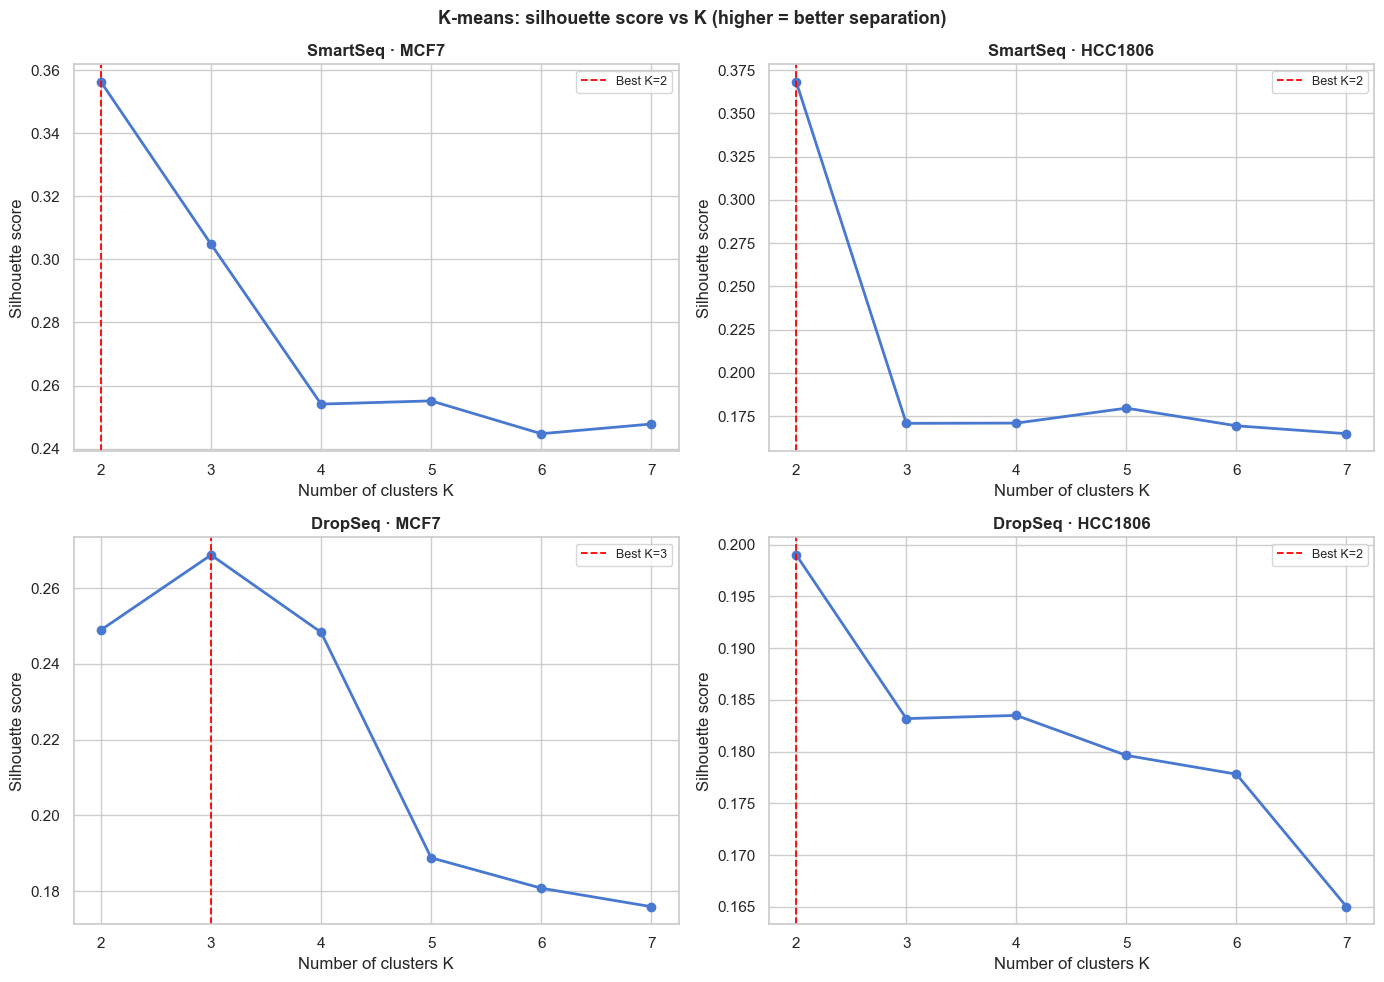

Saved: outputs/unsupervised_kmeans_silhouette.png


In [13]:
K_RANGE   = range(2, 8)
SIL_CAP   = 3000
sil_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (tech, line) in zip(axes, X_pca.keys()):
    X_cl = X_pca[(tech, line)]
    scores = []

    for k in K_RANGE:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_cl)

        if X_cl.shape[0] > SIL_CAP:
            idx_s = RNG.choice(X_cl.shape[0], SIL_CAP, replace=False)
            sil = silhouette_score(X_cl[idx_s], labels[idx_s])
        else:
            sil = silhouette_score(X_cl, labels)
        scores.append(sil)

    sil_results[(tech, line)] = scores
    best_k = list(K_RANGE)[np.argmax(scores)]

    ax.plot(list(K_RANGE), scores, marker='o', lw=2)
    ax.axvline(best_k, color='red', ls='--', lw=1.3, label=f'Best K={best_k}')
    ax.set_xlabel('Number of clusters K')
    ax.set_ylabel('Silhouette score')
    ax.set_title(f'{tech} · {line}', fontweight='bold')
    ax.set_xticks(list(K_RANGE))
    ax.legend(fontsize=9)

fig.suptitle('K-means: silhouette score vs K (higher = better separation)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / 'unsupervised_kmeans_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/unsupervised_kmeans_silhouette.png')

### Interpretation — Silhouette Scores & Optimal K

**What the plot shows:**
Each line shows how silhouette score changes as we try different numbers of clusters (K=2 to 7). Higher = better. The red dashed line marks the winning K. A score above 0.3 indicates reasonable structure; above 0.5 is strong.

**Interpretation:**
- **SmartSeq MCF7 and HCC1806:** Both peak sharply at K=2 then drop off. The data strongly prefers two clusters, which aligns perfectly with the two biological conditions (Hypoxia/Normoxia). Scores of ~0.36–0.37 are in the moderate-good range.
- **DropSeq HCC1806:** Also peaks at K=2 but with a much lower score (~0.20) and a flatter curve. The algorithm finds two groups but they are not well-separated, again due to dropout noise.
- **DropSeq MCF7:** The one exception. Peaks at K=3 instead of K=2. This could mean there is a genuine sub-population within one condition (e.g. cells at different stages of hypoxia response), or it could simply be noise creating a spurious extra cluster. Either way, K=2 is still biologically motivated and only marginally worse here.
- **Key message:** Three out of four datasets independently select K=2, matching the known biology without ever seeing the labels.

### 5.2 K-means clusters visualised in PCA space

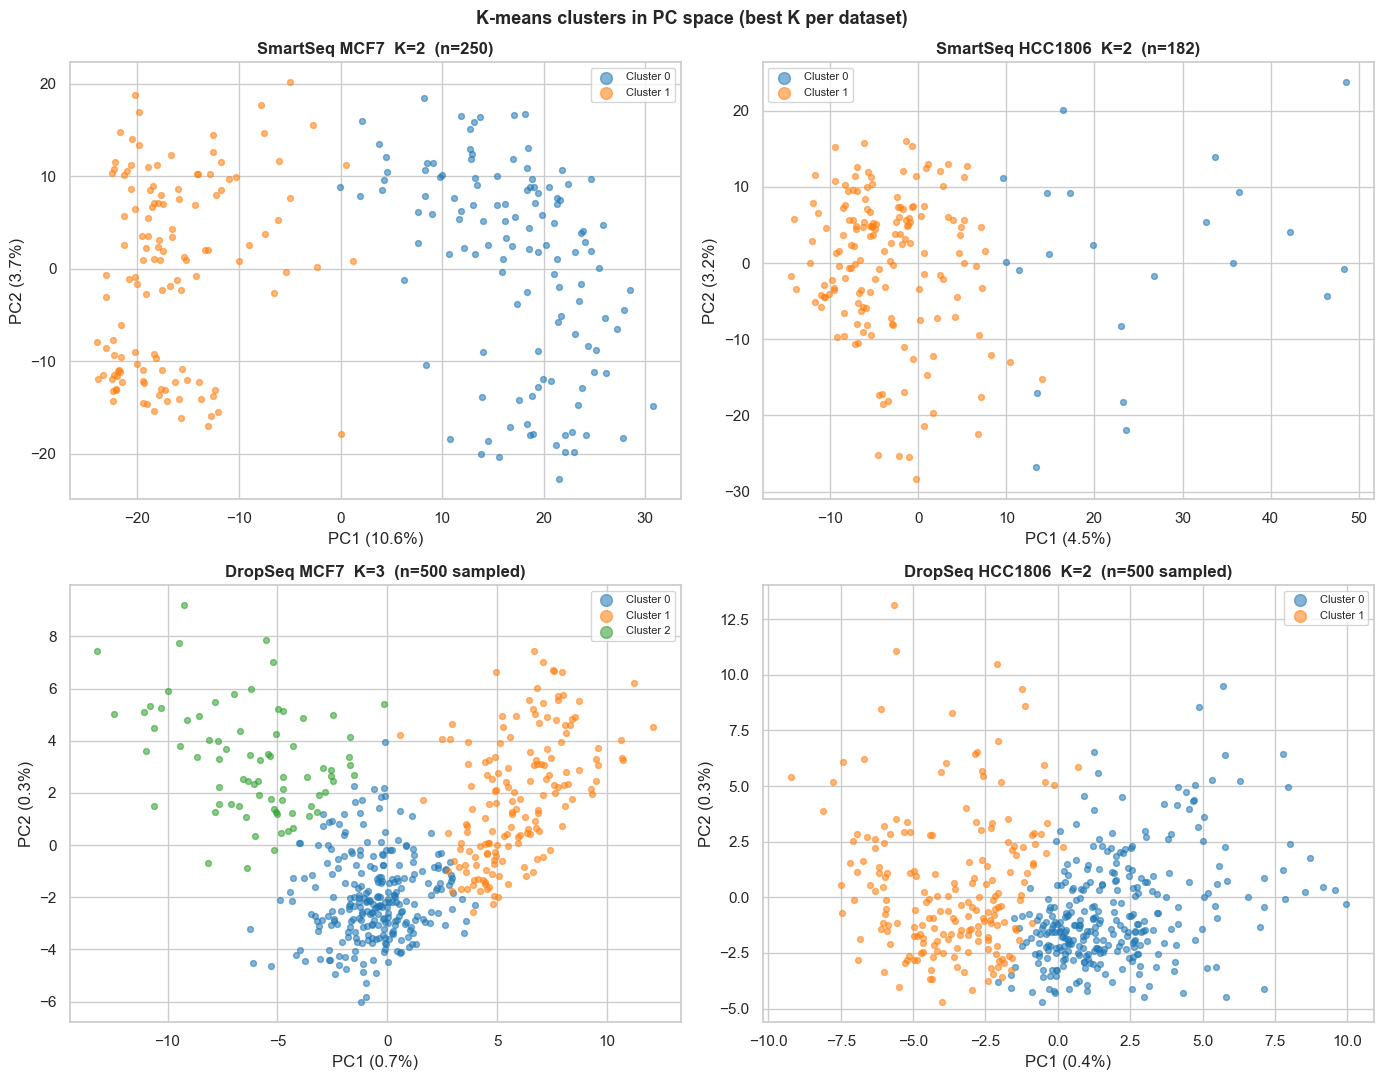

Saved: outputs/unsupervised_kmeans_pca.png


In [22]:
km_labels = {}
best_k_dict = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, ((tech, line), X_cl) in zip(axes, X_pca.items()):
    pca = pca_dict[(tech, line)]
    scores = scores_dict[(tech, line)]
    conds = cond_dict[(tech, line)]

    best_k = list(K_RANGE)[np.argmax(sil_results[(tech, line)])]
    best_k_dict[(tech, line)] = best_k

    km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cl)
    km_labels[(tech, line)] = labels

    if scores.shape[0] > MAX_SCATTER:
        idx = stratified_idx(conds, MAX_SCATTER, RNG)
        s_plot = scores[idx, :2]
        l_plot = labels[idx]
        note = f'n={len(idx)} sampled'
    else:
        s_plot, l_plot = scores[:, :2], labels
        note = f'n={scores.shape[0]}'

    palette = plt.cm.tab10.colors
    for cl in range(best_k):
        mask = l_plot == cl
        ax.scatter(s_plot[mask, 0], s_plot[mask, 1], color=palette[cl], alpha=0.55, s=18, label=f'Cluster {cl}', rasterized=True)

    ev1 = pca.explained_variance_ratio_[0] * 100
    ev2 = pca.explained_variance_ratio_[1] * 100
    ax.set_xlabel(f'PC1 ({ev1:.1f}%)')
    ax.set_ylabel(f'PC2 ({ev2:.1f}%)')
    ax.set_title(f'{tech} {line}  K={best_k}  ({note})', fontweight='bold')
    ax.legend(fontsize=8, markerscale=2)

fig.suptitle('K-means clusters in PC space (best K per dataset)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / 'unsupervised_kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/unsupervised_kmeans_pca.png')

### 5.3 Cluster vs condition contingency table

How much do the unsupervised K-means clusters align with the Hypoxia/Normoxia labels?  
Pure alignment (K=2, each cluster = one condition) would mean the transcriptomic signal fully separates the two groups without supervision.

In [20]:
for (tech, line), labels in km_labels.items():
    conds = cond_dict[(tech, line)]
    ct = pd.crosstab(pd.Series(labels, name='K-means cluster'), pd.Series(conds, name='Condition'))
    ct_pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(1)
    print(f"\n{'-'*55}")
    print(f"{tech} {line}(K={best_k_dict[(tech, line)]})")
    print(ct)
    print("Row % (how much of each cluster is Hypoxia vs Normoxia):")
    print(ct_pct)


-------------------------------------------------------
SmartSeq MCF7(K=2)
Condition        Hypoxia  Normoxia
K-means cluster                   
0                    123         0
1                      1       126
Row % (how much of each cluster is Hypoxia vs Normoxia):
Condition        Hypoxia  Normoxia
K-means cluster                   
0                100.000     0.000
1                  0.800    99.200

-------------------------------------------------------
SmartSeq HCC1806(K=2)
Condition        Hypoxia  Normoxia
K-means cluster                   
0                     15         7
1                     82        78
Row % (how much of each cluster is Hypoxia vs Normoxia):
Condition        Hypoxia  Normoxia
K-means cluster                   
0                 68.200    31.800
1                 51.200    48.800

-------------------------------------------------------
DropSeq MCF7(K=3)
Condition        Hypoxia  Normoxia
K-means cluster                   
0                   2608  

### Interpretation — Cluster vs Condition Contingency Tables

**What the tables show:**
How many cells from each condition (Hypoxia/Normoxia) ended up in each K-means cluster. If the clusters match the biology, each cluster should be dominated by one condition.

**Results:**
- **SmartSeq MCF7 (K=2):** Near-perfect match. Cluster 0 is 100% Hypoxia, cluster 1 is 99.2% Normoxia. Only 1 cell out of 250 was misassigned. K-means recovered the biology almost perfectly without ever seeing the labels.
- **SmartSeq HCC1806 (K=2):** Much weaker. Cluster 0 is 68% Hypoxia, cluster 1 is roughly 50/50. The algorithm finds two groups but they don't map cleanly onto the two conditions. Consistent with the messier PCA separation we saw earlier.
- **DropSeq MCF7 (K=3):** Cluster 1 is mostly Hypoxia (97.2%), but clusters 0 and 2 are both mostly Normoxia. The algorithm split Normoxia into two groups rather than finding a meaningful third biological class.
- **DropSeq HCC1806 (K=2):** Both clusters are mixed (~68/32 and ~48/52). No meaningful separation. The noise overwhelms the signal.

**Key message:** The quality of clustering degrades as data quality decreases. SmartSeq MCF7 is almost perfect, SmartSeq HCC1806 is partial, DropSeq is essentially random. This mirrors everything we've seen so far and confirms that the hypoxia signal is real but technology-dependent in how cleanly it can be recovered.

### 5.4 Hierarchical clustering (Ward linkage) + dendrograms

Hierarchical clustering builds a tree of cell merges bottom-up. **Ward linkage** minimises the total within-cluster variance at each merge — it produces compact, evenly-sized clusters.  

The dendrogram shows the merge hierarchy: cells at the bottom, with branches merging at heights corresponding to the Ward distance. A natural cut point separates the two main branches = two groups of cells.

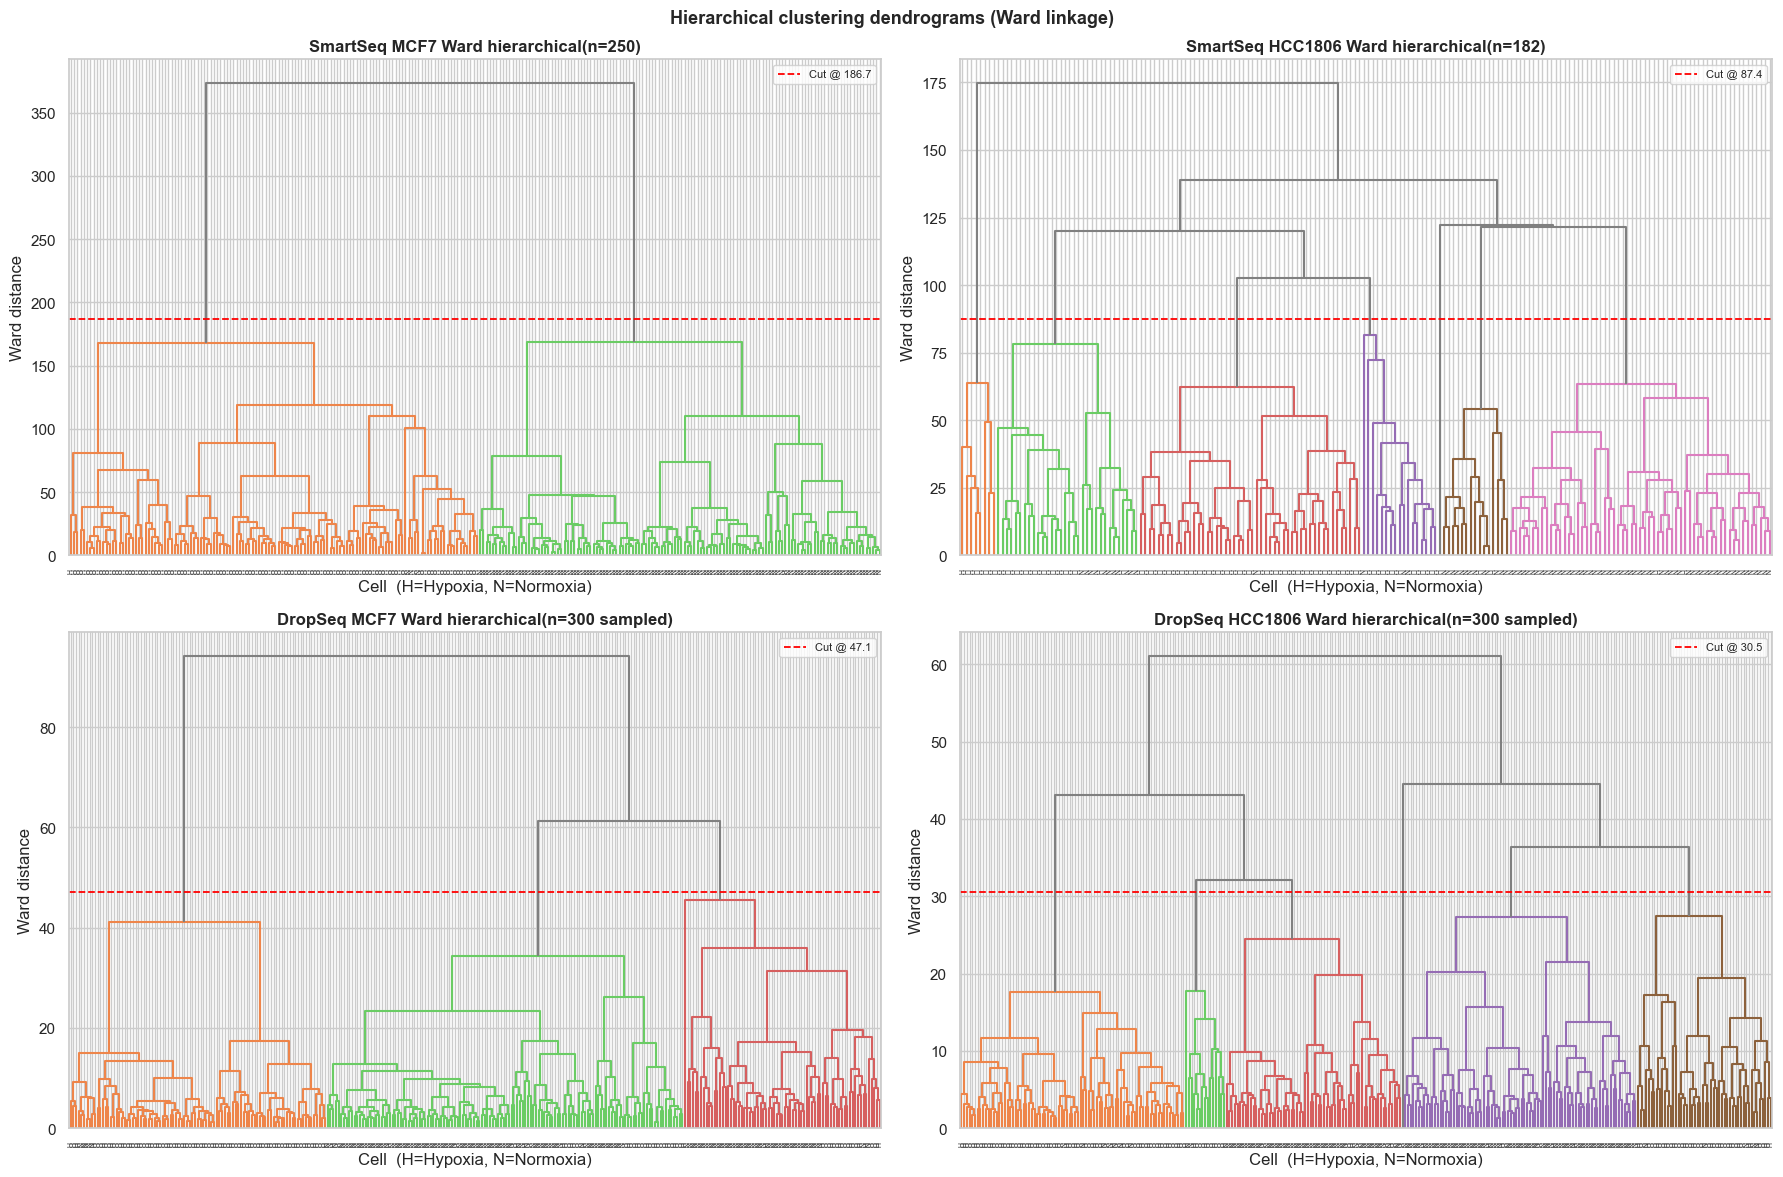

Saved: outputs/unsupervised_hierarchical_dendrograms.png


In [25]:
DENDRO_CAP = 300
hc_labels = {}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax, ((tech, line), X_cl) in zip(axes, X_pca.items()):
    conds = cond_dict[(tech, line)]
    best_k = best_k_dict[(tech, line)]

    if X_cl.shape[0] > DENDRO_CAP:
        idx = stratified_idx(conds, DENDRO_CAP, RNG)
        X_den = X_cl[idx]
        c_den = conds[idx]
        note = f'n={len(idx)} sampled'
    else:
        X_den, c_den = X_cl, conds
        note = f'n={X_cl.shape[0]}'

    Z = linkage(X_den, method='ward')
    color_thresh = 0.5 * Z[-1, 2] #cutoff at 50% of the max merge distance

    leaf_labels = ['H' if c == 'Hypoxia' else 'N' for c in c_den]
    dendrogram(Z, ax=ax, labels=leaf_labels, color_threshold=color_thresh, leaf_rotation=90, leaf_font_size=5, above_threshold_color='grey')

    ax.axhline(color_thresh, color='red', ls='--', lw=1.3, label=f'Cut @ {color_thresh:.1f}')
    ax.set_title(f'{tech} {line} Ward hierarchical({note})', fontweight='bold')
    ax.set_xlabel('Cell  (H=Hypoxia, N=Normoxia)')
    ax.set_ylabel('Ward distance')
    ax.legend(fontsize=8)

    hc = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
    hc_labels[(tech, line)] = hc.fit_predict(X_cl)

fig.suptitle('Hierarchical clustering dendrograms (Ward linkage)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / 'unsupervised_hierarchical_dendrograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/unsupervised_hierarchical_dendrograms.png') 

### Interpretation — Hierarchical Clustering Dendrograms

**What the plot shows:**
A dendrogram is a tree where each cell starts as its own leaf at the bottom and the algorithm progressively merges the most similar pairs upward. The height of each merge (y-axis = Ward distance) tells you how different the two groups being joined were. A high final merge means the last two groups were very distinct. The red dashed line is fixed at 50% of the maximum merge distance, acting as a threshold: if the two main branches are already clearly formed below that line, the data has clean two-group structure.

**Interpretation:**
- **SmartSeq MCF7:** One dominant split very high up. The two main branches are fully formed well below the red line, meaning the two groups are genuinely distinct. The dendrogram clearly supports K=2.
- **SmartSeq HCC1806 and DropSeq:** The tree fragments into many smaller branches at similar heights rather than two dominant ones. The red line cuts through a messy region rather than cleanly between two big branches, consistent with the weaker separation we've seen throughout: lower silhouette scores, overlapping PCA clouds, and mixed contingency tables.
- **Key message:** The dendrogram is most informative for SmartSeq MCF7, where the clean two-branch structure visually confirms the biology. For the noisier datasets it is less conclusive, but that itself is consistent with everything else we've found. Both hierarchical and K-means agree on K=2 for three out of four datasets, which makes the result more trustworthy regardless.

### 5.5 Silhouette score summary table — K-means vs Hierarchical

In [17]:
summary_rows = []

for (tech, line), X_cl in X_pca.items():
    best_k = best_k_dict[(tech, line)]

    if X_cl.shape[0] > SIL_CAP:
        idx_s = RNG.choice(X_cl.shape[0], SIL_CAP, replace=False)
    else:
        idx_s = np.arange(X_cl.shape[0])

    sil_km = silhouette_score(X_cl[idx_s], km_labels[(tech, line)][idx_s])
    sil_hc = silhouette_score(X_cl[idx_s], hc_labels[(tech, line)][idx_s])

    summary_rows.append({
        'Technology': tech, 'Cell line': line, 'K': best_k,
        'Silhouette K-means': round(sil_km, 4),
        'Silhouette Hierarchical': round(sil_hc, 4),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

Technology Cell line  K  Silhouette K-means  Silhouette Hierarchical
  SmartSeq      MCF7  2               0.356                    0.350
  SmartSeq   HCC1806  2               0.368                    0.459
   DropSeq      MCF7  3               0.271                    0.214
   DropSeq   HCC1806  2               0.207                    0.171


### Interpretation — Silhouette Summary Table

| Dataset | Best K | Silhouette K-means | Silhouette Hierarchical |
|---------|--------|--------------------|-------------------------|
| SmartSeq · MCF7 | 2 | 0.356 | 0.350 |
| SmartSeq · HCC1806 | 2 | 0.368 | 0.459 |
| DropSeq · MCF7 | 3 | 0.271 | 0.214 |
| DropSeq · HCC1806 | 2 | 0.207 | 0.171 |

**Interpretation:**
- **SmartSeq** scores (~0.35–0.46) are above the 0.3 threshold for meaningful cluster structure. Both methods agree on K=2, consistent with everything we've seen.
- **DropSeq** scores (~0.17–0.27) are weaker but not zero. The biological signal is there but partially drowned out by dropout noise.
- **K-means and hierarchical give similar scores across all four datasets**, which is reassuring. Two different algorithms reaching the same conclusion reduces the chance it's a coincidence or a quirk of one method.
- **Bottom line:** Cluster quality tracks data quality. SmartSeq separates cleanly, DropSeq less so, exactly the pattern we've seen throughout every section of this analysis.

## 6. Cross-dataset comparison

We compare the unsupervised structure along two axes:

**Axis 1 — Cell line:** MCF7 vs HCC1806 within the same sequencing technology.  
**Axis 2 — Technology:** SmartSeq vs DropSeq for the same cell line.

Since each dataset has its own PCA space (fitted on its own genes), we overlay the PC1–PC2 scatter plots side by side — the absolute coordinates differ, but we can compare the *degree of separation* between Hypoxia and Normoxia.

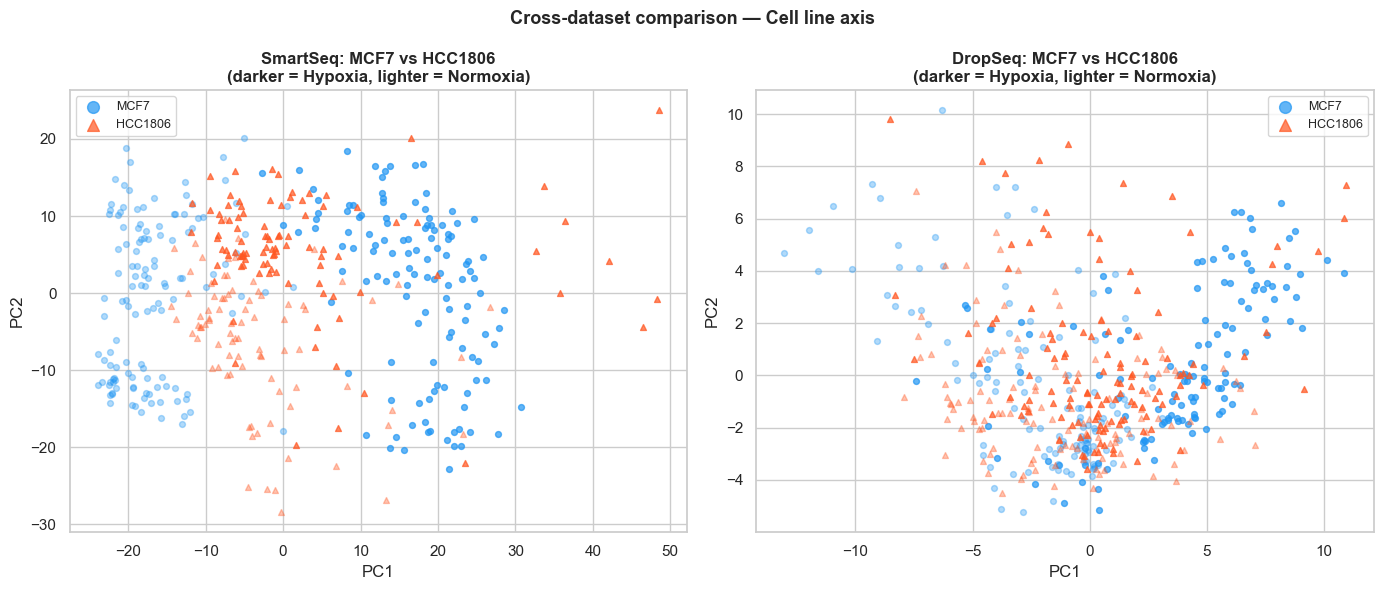

Saved: outputs/unsupervised_cross_cellline.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, tech in zip(axes, ['SmartSeq', 'DropSeq']):
    for line, marker, color in [('MCF7', 'o', '#2196F3'), ('HCC1806', '^', '#FF5722')]:
        scores = scores_dict[(tech, line)]
        conds  = cond_dict[(tech, line)]

        if scores.shape[0] > MAX_SCATTER // 2:
            idx = stratified_idx(conds, MAX_SCATTER // 2, RNG)
            s_plot = scores[idx, :2]
            c_plot = conds[idx]
        else:
            s_plot, c_plot = scores[:, :2], conds

        for cond, alpha in [('Hypoxia', 0.7), ('Normoxia', 0.35)]:
            mask = c_plot == cond
            lbl = f'{line}' if cond == 'Hypoxia' else None
            ax.scatter(s_plot[mask, 0], s_plot[mask, 1], color=color, marker=marker, alpha=alpha, s=18, label=lbl, rasterized=True)

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'{tech}: MCF7 vs HCC1806\n(darker = Hypoxia, lighter = Normoxia)', fontweight='bold')
    ax.legend(fontsize=9, markerscale=2)

fig.suptitle('Cross-dataset comparison — Cell line axis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / 'unsupervised_cross_cellline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/unsupervised_cross_cellline.png')

### Interpretation — Cross-Dataset Comparison: Cell-Line Axis

**What the plot shows:**
Both cell lines are overlaid on the same PCA axes at once: blue circles = MCF7, orange triangles = HCC1806, darker shade = Hypoxia, lighter = Normoxia. This is the first time we compare two biologically different cell lines directly rather than analysing each in isolation.

**Interpretation:**
- **SmartSeq:** The two clouds overlap but don't sit on top of each other. MCF7 and HCC1806 occupy somewhat different regions of PCA space, reflecting their different baseline expression profiles (MCF7 = ER+ luminal, HCC1806 = triple-negative basal). Within each cloud, the dark/light shade separation is visible, confirming the hypoxia signal exists in both cell lines.
- **DropSeq:** Both clouds are heavily mixed and largely overlapping. The noise overwhelms any cell-line separation, consistent with everything we've seen for DropSeq throughout.
- **Key message:** The two cell lines have different enough baseline expression that a classifier trained on one may not transfer cleanly to the other. The PCA space shifts between them. However the hypoxia response is present in both, just from different starting points. This is exactly why Person E's cross-cell-line generalisation test is necessary.

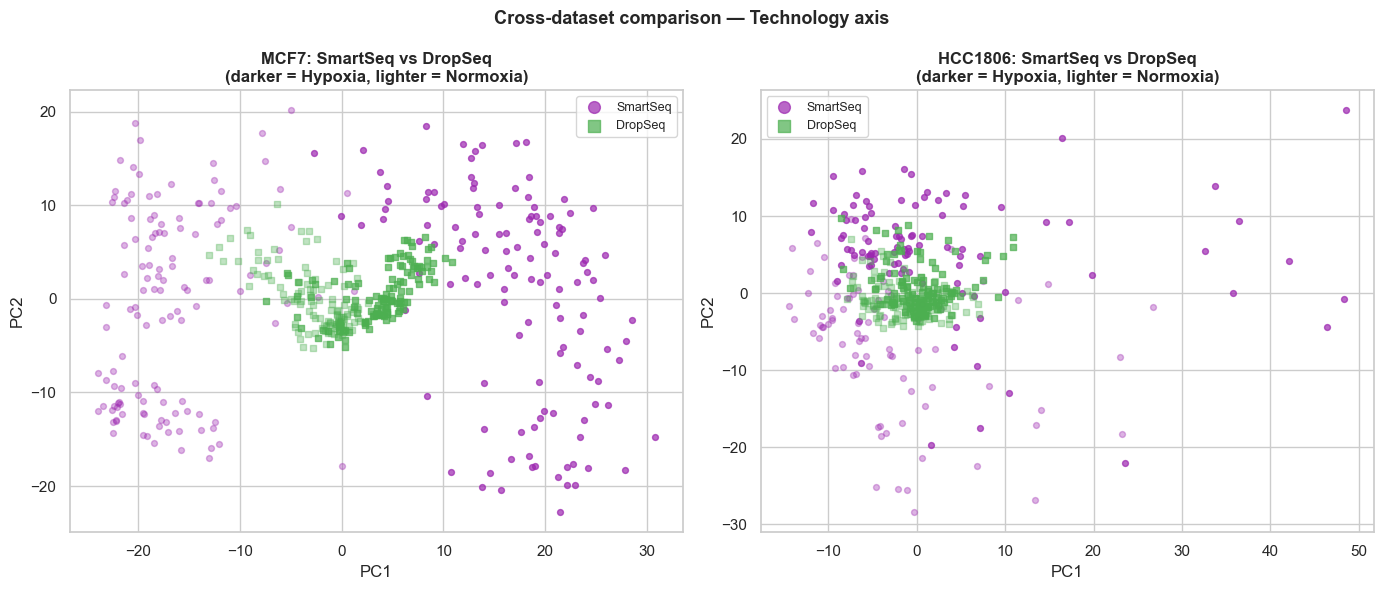

Saved: outputs/unsupervised_cross_technology.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, line in zip(axes, ['MCF7', 'HCC1806']):
    for tech, marker, color in [('SmartSeq', 'o', '#9C27B0'), ('DropSeq', 's', '#4CAF50')]:
        scores = scores_dict[(tech, line)]
        conds = cond_dict[(tech, line)]

        if scores.shape[0] > MAX_SCATTER // 2:
            idx = stratified_idx(conds, MAX_SCATTER // 2, RNG)
            s_plot = scores[idx, :2]
            c_plot = conds[idx]
        else:
            s_plot, c_plot = scores[:, :2], conds

        for cond, alpha in [('Hypoxia', 0.7), ('Normoxia', 0.35)]:
            mask = c_plot == cond
            lbl = f'{tech}' if cond == 'Hypoxia' else None
            ax.scatter(s_plot[mask, 0], s_plot[mask, 1], color=color, marker=marker, alpha=alpha, s=18, label=lbl, rasterized=True)

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'{line}: SmartSeq vs DropSeq\n(darker = Hypoxia, lighter = Normoxia)', fontweight='bold')
    ax.legend(fontsize=9, markerscale=2)

fig.suptitle('Cross-dataset comparison — Technology axis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / 'unsupervised_cross_technology.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/unsupervised_cross_technology.png')

### Interpretation — Cross-Dataset Comparison: Technology Axis

**What the plot shows:**
Same cell line, two technologies overlaid: purple = SmartSeq, green = DropSeq, darker shade = Hypoxia, lighter = Normoxia. This asks whether the two technologies produce a compatible view of the same biology.

**Interpretation:**
- **SmartSeq** cells are spread out widely across both axes with clear dark/light separation. Deep sequencing produces distinct profiles that PCA can spread apart cleanly.
- **DropSeq** cells are compressed into a tight cluster near the centre. Shallow sequencing with high dropout produces flat, similar-looking profiles that PCA can't spread out as much.
- Despite this, both technologies show the same directional trend for Hypoxia vs Normoxia. The hypoxia signal points the same way regardless of technology.
- **Key message:** The hypoxia signal is technology-robust. SmartSeq gives a cleaner picture, DropSeq a noisier one, but both are capturing the same underlying biology.

## 7. Results Summary & Interpretation

### Correlation Heatmaps
The SmartSeq MCF7 heatmap shows a clear block-diagonal structure. Hypoxia cells are similar to each other, Normoxia cells are similar to each other, and the two conditions are dissimilar to each other. This confirms that hypoxia is the dominant driver of cell-to-cell expression differences, not noise or batch effects. SmartSeq HCC1806 shows the same pattern but weaker. DropSeq heatmaps are flat due to dropout, not because the biology is absent, but because per-cell correlations collapse toward zero when most gene values are zero. The 4 outlier cells flagged in SmartSeq HCC1806 should be reviewed by Person D before classifier training.

### PCA Scree Plots
SmartSeq shows a clear elbow after PC1–PC2, with PC1 alone explaining 10.6% (MCF7) and 4.5% (HCC1806) of variance. The hypoxia response is concentrated in the first few components. DropSeq shows no elbow and only ~3% variance in the top 30 PCs, dropout spreads variance thinly across thousands of dimensions. All four datasets hit the 10 PC cap before reaching 80% variance, so clustering uses the top 10 PCs throughout.

### PC1 vs PC2 Scatter
SmartSeq MCF7 shows the clearest separation: two distinct clouds along PC1, with PCA recovering the Hypoxia/Normoxia split without ever seeing the labels. SmartSeq HCC1806 shows good but messier separation. DropSeq shows heavy overlap due to noise, though a directional trend is still visible. The key message: the hypoxia signal is the dominant source of variation in these cells, which predicts that classifiers will have a strong signal to learn from.

### Clustering
K=2 was the optimal number of clusters in three out of four datasets, matching the two biological conditions. SmartSeq MCF7 was near-perfect: 249 out of 250 cells correctly grouped without labels. SmartSeq HCC1806 was partial. DropSeq results were weak due to noise, with DropSeq MCF7 preferring K=3, likely a noise artefact rather than a genuine third biological group. Silhouette scores ranged from 0.35–0.46 for SmartSeq (meaningful structure) and 0.17–0.27 for DropSeq (weak but non-zero). Both K-means and hierarchical clustering agreed across all four datasets, making the findings more trustworthy.

### Cross-Dataset Comparison
**Cell-line axis (MCF7 vs HCC1806):** The two cell lines occupy different regions of PCA space, their baseline expression profiles are biologically distinct (MCF7 = ER+ luminal, HCC1806 = triple-negative basal). However the hypoxia response is present in both, just from different starting points. This means a classifier trained on one cell line may not transfer directly to the other.

**Technology axis (SmartSeq vs DropSeq):** SmartSeq cells are spread wide and well-separated; DropSeq cells compress into a tight cluster near the centre. Despite this, both technologies show the hypoxia signal pointing in the same direction. The biology is technology-robust even if the clarity is not.

### Alternative Dimensionality Reduction Methods
PCA was used here because it is linear, interpretable, and fast. Other methods exist and would be natural next steps:

| Method | Key property | Limitation |
|--------|-------------|------------|
| **UMAP** | Preserves local + global structure; standard for scRNA-seq | Non-linear; distances not directly interpretable |
| **t-SNE** | Excellent local cluster separation | Distances between clusters meaningless; slow on large N |
| **NMF** | Parts-based (non-negative); interpretable gene programmes | Requires non-negative input; more hyperparameters |
| **ICA** | Separates statistically independent sources | Harder to interpret; sign ambiguity |

UMAP is the standard follow-up to PCA in modern scRNA-seq pipelines and would be the natural next step for this project.